In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Required to import shared functions
import sys
sys.path.append('../src/')

In [83]:
#Importing shared .py file containing shared functions
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [94]:
#Importing Cosmological Pars and original power spectrum functions

from utils import h, Om_m, Om_b, Om_lambda, rho_c, delta_c, sigma8_obs, n, z_range, f_b, H0, H, W, T, D, P, Pi, sigma_R, sigma_M, A

## Original Power Spectrum

In [95]:
# Evaluate and print the normalization factor
R8 = 8/h      # units of Mpc

A = sigma8_obs/sigma_R(R8,0)
print(sigma_R(R8,0,np.inf))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A}")

0.00022314453983950192
Normalization factor A for sigma_8 = 0.811 is A = 3634.415615023862


In [90]:
from scipy.integrate import quad

In [98]:
k_range = np.linspace(1, 999)
P_old_test_vals = np.zeros((len(z_range), len(k_range)))

for i in range(len(z_range)):
    for j in range(len(k_range)):
        P_old_test_vals[i][j] = A * P(k_range[j], z_range[i], cutoff = 1000)

## New Power Spectrum

In [99]:
def P_new(k, z, A_G, k_mean, k_var, cutoff=np.inf): #Power spectrum evolution
    if k<=cutoff:    
        return Pi_new(k, A_G, k_mean, k_var)*(T(k)*D(z))**2
    else:
        return 0

# Primordial power spectrum (un-normalised)
def Pi_new(k, A_G, k_mean, k_var):
    return k ** n * (1 + A_G * np.e ** (-1 / 2 * ((np.log10(k / k_mean)) / k_var) ** 2))

In [100]:
# Variance of smoothed density field (wrt radius, R)
def sigma_R_new(R, A_G, k_mean, k_var, z=0, cutoff=1000):    
    # Integrand for the variance calculation
    def integral(k):
        return P_new(k, z, A_G, k_mean, k_var, cutoff) * k**2 * W(k,R)**2 / (2 * np.pi**2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=500, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)


# Variance of smoothed density field (wrt mass of region, M)
def sigma_M_new(M, A_G, k_mean, k_var, z=0, cutoff=1000):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * rho_0))**(1/3)
    
    return sigma_R_new(R,z, A_G, k_mean, k_var, cutoff)

In [101]:
#Gaussian Parameters

A_G_val = 100
k_mean_val = np.array([30, 100, 300])
k_var_val = 0.5

In [102]:
# Evaluate and print the normalization factor

A_new = sigma8_obs/sigma_R_new(R8, A_G_val, k_mean_val[1], k_var_val, 0)
print(sigma_R_new(R8, A_G_val, k_mean_val[1], k_var_val, 0,np.inf))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A_new}")

0.00022315978835224154
Normalization factor A for sigma_8 = 0.811 is A = 3634.1672753332036


In [103]:
P_test_vals = np.zeros((len(k_mean_val), len(z_range), len(k_range)))

for p in range(len(k_mean_val)):
    for i in range(len(z_range)):
        for j in range(len(k_range)):
            P_test_vals[p, i, j] = A_new * P_new(k_range[j], z_range[i], A_G_val, k_mean_val[p], k_var_val, cutoff=1000)

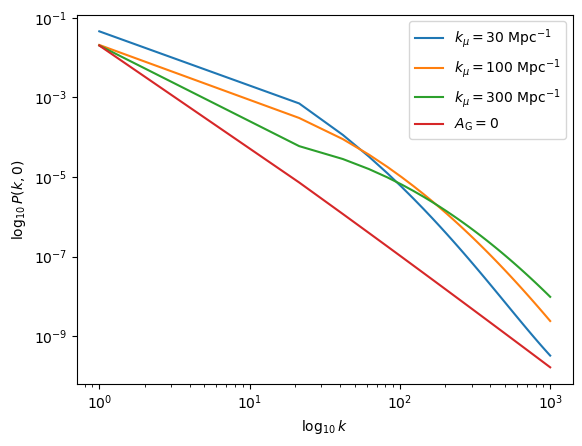

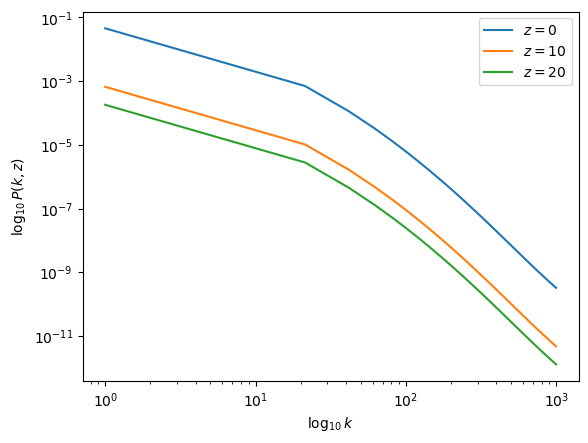

In [114]:
#Const A_G, const z
plt.loglog(k_range, P_test_vals[0][0], label = r'$k_\mu=30$ Mpc$^{-1}$')
plt.loglog(k_range, P_test_vals[1][0], label = r'$k_\mu=100$ Mpc$^{-1}$')
plt.loglog(k_range, P_test_vals[2][0], label = r'$k_\mu=300$ Mpc$^{-1}$')

plt.loglog(k_range, P_old_test_vals[0], label = r'$A_\text{G}=0$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,0)$')

plt.legend()
plt.show()

#const A_G, const k_\mu

plt.loglog(k_range, P_test_vals[0][0], label = r'$z=0$')
plt.loglog(k_range, P_test_vals[0][49], label = r'$z=10$')
plt.loglog(k_range, P_test_vals[0][99], label = r'$z=20$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,z)$')

plt.legend()
plt.show()

In [110]:
z_range[49]

np.float64(9.949494949494948)